In [ ]:
import os
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Path
# =========================
DATA_DIR = r"\data\input"
CSV_PATH = os.path.join(DATA_DIR, "UAV.csv")

MODEL_DIR = os.path.join(DATA_DIR, "UAV", "RandomForest")
SAVE_DIR = os.path.join(MODEL_DIR, "SHAP")
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================
# Load data
# =========================
raw = pd.read_csv(CSV_PATH, encoding="gbk")
raw.columns = raw.columns.astype(str).str.strip()
# change the name of the 165th column to "WT" (Python index 164)
raw.columns.values[164] = "WT"
max_feat = max(165, raw.shape[1])
features = raw.iloc[:, :max_feat].copy()

target_col = "DO(mg/L"

if target_col not in raw.columns:
    raise ValueError(f"{target_col} not found.")

X_df = features.copy()

if target_col in X_df.columns:
    X_df = X_df.drop(columns=[target_col])

X = X_df.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(raw[target_col], errors="coerce")

data = pd.concat([X, y], axis=1).dropna()

X = data.iloc[:, :-1].values
feature_names = X_df.columns.tolist()

print("Samples:", X.shape[0])
print("Features:", X.shape[1])

# =========================
# SHAP for each fold
# =========================
for fold in range(5):

    print(f"\n========== Fold {fold} ==========")

    model_path = os.path.join(MODEL_DIR, f"rf_fold{fold}.pkl")

    model = joblib.load(model_path)

    print("Model Loaded.")

    # TreeExplainer
    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X)

    # =====================
    # Summary Plot
    # =====================
    plt.figure(figsize=(8,6))

    shap.summary_plot(
        shap_values,
        X,
        feature_names=feature_names,
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            SAVE_DIR,
            f"Fold{fold}_Summary.png"
        ),
        dpi=600,
        bbox_inches="tight"
    )

    plt.close()

    # =====================
    # Bar Plot
    # =====================
    plt.figure(figsize=(8,6))

    shap.summary_plot(
        shap_values,
        X,
        feature_names=feature_names,
        plot_type="bar",
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            SAVE_DIR,
            f"Fold{fold}_Bar.png"
        ),
        dpi=600,
        bbox_inches="tight"
    )

    plt.close()

    # =====================
    # SHAP values
    # =====================
    shap_df = pd.DataFrame(
        shap_values,
        columns=feature_names
    )

    shap_df.to_csv(
        os.path.join(
            SAVE_DIR,
            f"Fold{fold}_SHAP_values.csv"
        ),
        index=False,
        encoding="utf-8-sig"
    )

    # =====================
    # Mean |SHAP|
    # =====================
    importance = np.abs(shap_values).mean(axis=0)

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Mean_SHAP": importance
    })

    importance_df = importance_df.sort_values(
        by="Mean_SHAP",
        ascending=False
    )

    importance_df.to_csv(
        os.path.join(
            SAVE_DIR,
            f"Fold{fold}_Importance.csv"
        ),
        index=False,
        encoding="utf-8-sig"
    )

    print("Finished.")

print("\nAll SHAP analyses completed.")

Samples: 570
Features: 165

========== Fold 0 ==========
Model Loaded.


d:\anaconda3\envs\GNN\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\anaconda3\envs\GNN\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.6.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Finished.

========== Fold 1 ==========
Model Loaded.
Finished.

========== Fold 2 ==========
Model Loaded.
Finished.

========== Fold 3 ==========
Model Loaded.
Finished.

========== Fold 4 ==========
Model Loaded.
Finished.

All SHAP analyses completed.


In [ ]:
import os
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Global style 
# =========================
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 8

# =========================
# Path
# =========================
DATA_DIR = r"\data\input"
CSV_PATH = os.path.join(DATA_DIR, "UAV.csv")

MODEL_DIR = os.path.join(DATA_DIR, "UAV", "RandomForest")
SAVE_DIR = os.path.join(MODEL_DIR, "SHAP")
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================
# Load data
# =========================
raw = pd.read_csv(CSV_PATH, encoding="gbk")
raw.columns = raw.columns.astype(str).str.strip()

raw.columns.values[164] = "WT"

max_feat = max(165, raw.shape[1])
features = raw.iloc[:, :max_feat].copy()

target_col = "DO(mg/L"

if target_col not in raw.columns:
    raise ValueError(f"{target_col} not found.")

X_df = features.copy()

if target_col in X_df.columns:
    X_df = X_df.drop(columns=[target_col])

X = X_df.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(raw[target_col], errors="coerce")

data = pd.concat([X, y], axis=1).dropna()

X = data.iloc[:, :-1].values
feature_names = X_df.columns.tolist()

print("Samples:", X.shape[0])
print("Features:", X.shape[1])

# =========================
# SHAP analysis per fold
# =========================
for fold in range(5):

    print(f"\n========== Fold {fold} ==========")

    model_path = os.path.join(MODEL_DIR, f"rf_fold{fold}.pkl")
    model = joblib.load(model_path)

    print("Model Loaded.")

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    # =========================
    # select top10 features
    # =========================
    importance = np.abs(shap_values).mean(axis=0)

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Mean_SHAP": importance
    }).sort_values(by="Mean_SHAP", ascending=False)

    top_features = importance_df["Feature"].head(10).values
    top_idx = [feature_names.index(f) for f in top_features]

    # =========================
    # Only keep top10 features
    # =========================
    X_top = X[:, top_idx]
    shap_top = shap_values[:, top_idx]

    # =========================
    # Figure size (14.65 cm, 8:3)
    # =========================
    fig_width = 14.65 / 2.54
    fig_height = fig_width * 5 / 8

    fig, axes = plt.subplots(1, 2, figsize=(fig_width, fig_height))

    # =========================
    # (1) SHAP beeswarm TOP10
    # =========================
    plt.sca(axes[0])

    shap.summary_plot(
        shap_top,
        X_top,
        feature_names=top_features,
        show=False,
        plot_size=None
    )

    axes[0].set_title("Top10 SHAP Summary", fontsize=10)
    axes[0].set_xlabel("SHAP value")

    # =========================
    # (2) SHAP bar TOP10
    # =========================
    plt.sca(axes[1])

    shap.summary_plot(
        shap_top,
        X_top,
        feature_names=top_features,
        plot_type="bar",
        show=False,
        plot_size=None
    )

    axes[1].set_title("Top10 Feature Importance", fontsize=10)
    axes[1].set_xlabel("mean(|SHAP value|)")

    # =========================
    # layout
    # =========================
    plt.tight_layout()

    save_path = os.path.join(SAVE_DIR, f"Fold{fold}_SHAP_top10.png")
    plt.savefig(save_path, dpi=600, bbox_inches="tight")

    plt.close()

    # =========================
    # Save SHAP values
    # =========================
    shap_df = pd.DataFrame(shap_values, columns=feature_names)
    shap_df.to_csv(
        os.path.join(SAVE_DIR, f"Fold{fold}_SHAP_values.csv"),
        index=False,
        encoding="utf-8-sig"
    )

    # =========================
    # Mean |SHAP|
    # =========================
    importance = np.abs(shap_values).mean(axis=0)

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Mean_SHAP": importance
    }).sort_values(by="Mean_SHAP", ascending=False)

    importance_df.to_csv(
        os.path.join(SAVE_DIR, f"Fold{fold}_Importance.csv"),
        index=False,
        encoding="utf-8-sig"
    )

    print("Finished.")

print("\nAll SHAP analyses completed.")

Samples: 570
Features: 165

========== Fold 0 ==========
Model Loaded.


d:\anaconda3\envs\GNN\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\anaconda3\envs\GNN\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.6.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Finished.

========== Fold 1 ==========
Model Loaded.
Finished.

========== Fold 2 ==========
Model Loaded.
Finished.

========== Fold 3 ==========
Model Loaded.
Finished.

========== Fold 4 ==========
Model Loaded.
Finished.

All SHAP analyses completed.


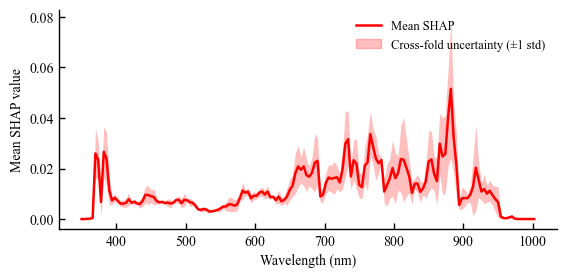

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===========================
# Path
# ===========================
MODEL_DIR = r"\data\input\UAV\RandomForest\SHAP"

all_importance = []

for fold in range(5):

    file = os.path.join(
        MODEL_DIR,
        f"Fold{fold}_Importance.csv"
    )

    df = pd.read_csv(file)

    # del WT
    df = df[df["Feature"] != "WT"]

    df["Feature"] = df["Feature"].astype(float)

    # sort by Feature (wavelength)
    df = df.sort_values("Feature")

    all_importance.append(df["Mean_SHAP"].values)

all_importance = np.array(all_importance)

# mean ± std
mean_shap = all_importance.mean(axis=0)
std_shap = all_importance.std(axis=0)

# wavelength values
wavelength = df["Feature"].values

# ===========================
# Figure settings
# ===========================
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 10

# cm -> inch
width = 14.65 / 2.54
height = width / 2

fig, ax = plt.subplots(figsize=(width, height))

# Mean curve
ax.plot(
    wavelength,
    mean_shap,
    color="red",
    linewidth=1.8,
    label="Mean SHAP"
)

# Std band
ax.fill_between(
    wavelength,
    mean_shap - std_shap,
    mean_shap + std_shap,
    color="red",
    alpha=0.25,
    linewidth=0
)

# Labels
ax.set_xlabel("Wavelength (nm)", fontsize=10)
ax.set_ylabel("Mean SHAP value", fontsize=10)

# Tick parameters
ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    length=4,
    width=1,
    labelsize=10
)

ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    length=2
)

# Remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Spine width
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# =========================
# Custom legend handles
# =========================
mean_line = mlines.Line2D(
    [],
    [],
    color="red",
    linewidth=1.8,
    label="Mean SHAP"
)

uncertainty_patch = mpatches.Patch(
    color="red",
    alpha=0.25,
    label="Cross-fold uncertainty (±1 std)"
)

ax.legend(
    handles=[mean_line, uncertainty_patch],
    frameon=False,
    fontsize=9,
    loc="best"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        MODEL_DIR,
        "Spectral_SHAP_Mean_STD.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [14]:
max_idx = np.argmax(mean_shap)

max_wavelength = wavelength[max_idx]
max_value = mean_shap[max_idx]
std_value = std_shap[max_idx]

print("Max SHAP value:", max_value)
print("std SHAP value:", std_value)
print("Corresponding wavelength:", max_wavelength)

Max SHAP value: 0.051563643409797535
std SHAP value: 0.027384459191850757
Corresponding wavelength: 882.0
